# 00 — Pandas + NumPy на Advertising

Этот ноутбук — стартовая точка всего ML-блока (недели 7-10). Здесь мы установим библиотеки, познакомимся с DataFrame и numpy-массивом, посмотрим на реальные данные (рекламные бюджеты и продажи) и попрактикуемся в фильтрации, EDA и построении первых графиков.

## Импорты

Jupyter уже стоит в env `mentoring`. `pandas`, `numpy`, `matplotlib`, `seaborn` устанавливаются командой из материала урока («Что устанавливаем перед ML-блоком»). Здесь только импорты с алиасами, которые встретятся во всех ноутбуках недели.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Проверим, что всё установилось и какие версии у нас стоят.
# В реальной работе версии часто важны — у sklearn API меняется между релизами.
print(f'pandas:     {pd.__version__}')
print(f'numpy:      {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn:    {sns.__version__}')

pandas:     2.2.2
numpy:      1.26.4
matplotlib: 3.9.2
seaborn:    0.13.2


Если все версии напечатались без ошибки — окружение готово. Если выскочил `ModuleNotFoundError` — запусти команду `pip install ...` из материала урока в активированном env `mentoring`.

## О датасете

В этом ноутбуке (и в большинстве примеров в `02_*`) используем **Advertising.csv** — классический учебный датасет по маркетингу. 200 строк, каждая строка — рекламная кампания. Колонки `TV`, `radio`, `newspaper` — бюджеты (в тысячах долларов), вложенные в рекламу по каналу. Колонка `sales` — продажи, которые получились в результате (в тысячах единиц товара).

| Колонка | Тип | Описание |
|---|---|---|
| `TV` | float | Бюджет на TV-рекламу, тыс. долл. |
| `radio` | float | Бюджет на радио, тыс. долл. |
| `newspaper` | float | Бюджет на газеты, тыс. долл. |
| `sales` | float | Продажи продукта, тыс. единиц |

Размер: 200 строк × 4 колонки.

**Бизнес-задача:** маркетинг-команда хочет понять, какой канал даёт больше отдачи на каждый вложенный доллар. Линрег покажет, какие коэффициенты при `TV/radio/newspaper` — это ровно то, что нужно для разговора с CMO.

### Зачем вообще смотреть на данные перед моделью

Данные — это **80% успеха ML-проекта**. Перед тем как обучать что-то, надо понять: с чем работаешь, какие колонки есть, какие распределения, есть ли выбросы и пропуски. EDA (exploratory data analysis) — не формальность; модель, обученная на грязных данных, выдаст красивые метрики на отчёте, которые в проде развалятся в первый день. Поэтому стандартный workflow — сначала несколько базовых проверок (`shape`, `info`, `describe`, `isna`, `duplicated`, гистограммы, scatter), и только потом — `model.fit()`.


---

## Pandas: основные команды

Что мы будем вызывать в этом разделе:

- `pd.read_csv(path)` — читает CSV-файл и возвращает DataFrame.
- `df.head(n)` — первые `n` строк таблицы (по умолчанию 5).
- `df.shape` — кортеж `(строк, колонок)`.
- `df.info()` — типы колонок и количество пропусков.
- `df.describe()` — сводная статистика по числовым колонкам.

### Загружаем датасет

Будем работать с классическим учебным датасетом **Advertising** — 200 наблюдений по рекламным бюджетам компании. Колонки: `TV`, `radio`, `newspaper` (бюджеты в тысячах долларов) и `sales` (продажи в тысячах единиц). Бизнес-вопрос: какие каналы реально приносят выручку.

In [2]:
df = pd.read_csv('data/Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Пять строк сразу дают почувствовать данные: бюджеты разнокалиберные (TV — сотни тысяч, newspaper — десятки), продажи — однозначные числа. В жизни первое, что делает аналитик после загрузки — именно `head()`, чтобы убедиться, что распарсилось как надо (а не вся строка попала в одну колонку).

### Размер и типы

Дальше — `shape` и `info()`. `shape` отвечает «сколько вообще объектов», `info()` — какие типы и есть ли пропуски.

In [3]:
print(f'Размер датасета: {df.shape}')
df.info()

Размер датасета: (200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


200 строк, 4 числовые колонки, **пропусков нет** (Non-Null Count = 200 везде). В реальных данных эту проверку никогда не пропускают — пропуски ломают обучение sklearn-моделей (выкинет `ValueError: Input contains NaN`).

### Сводная статистика

`describe()` даёт распределение каждой числовой колонки одним вызовом.

In [4]:
df.describe().round(2)

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


Что мы здесь видим:

- TV-бюджеты варьируются от $0.7K до $296K (огромный разброс).
- Newspaper-бюджеты в среднем $30K, но 75-й перцентиль $45K — длинный правый хвост.
- Продажи (`sales`) от 1.6K до 27K единиц.

Если бы где-то увидели «возраст 250 лет» или «зарплата $1M медианная» — это сигнал к чистке данных.

---

## Чистка данных: пропуски, дубли, выбросы

Перед обучением модели любую таблицу нужно проверить на три типичные проблемы. Покажем приёмы прямо на этом датасете (формально он чистый, но мы продемонстрируем команды).

### 1. Пропущенные значения (NaN)

Что мы будем вызывать:

- `df.isna()` — DataFrame того же размера с булевыми значениями (True там, где NaN).
- `df.isna().sum()` — сумма по колонкам = сколько NaN в каждой.
- `df.dropna()` — выбросить строки с NaN.
- `df.fillna(value)` — заполнить NaN значением (медианой, средним, 0, ...).

In [5]:
# Считаем пропуски в каждой колонке.
df.isna().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

Все нули — пропусков нет. Если бы было, например, `radio: 12`, мы могли бы:

1. **Выбросить строки с пропусками** — `df.dropna()`. Подходит, если пропусков мало (<5%).
2. **Заполнить медианой** — `df['radio'].fillna(df['radio'].median())`.    Не теряем строки, но искажаем распределение.
3. **Использовать модель**, которая умеет работать с NaN (например, `HistGradientBoostingRegressor`).

Покажем технику заполнения медианой на копии:

In [6]:
# Демонстрация: специально создадим пропуски в копии и заполним их.
df_with_gaps = df.copy()
df_with_gaps.loc[[5, 10, 15], 'radio'] = np.nan  # вручную ставим NaN
print('До заполнения, NaN в radio:', df_with_gaps['radio'].isna().sum())

median_radio = df_with_gaps['radio'].median()
df_with_gaps['radio'] = df_with_gaps['radio'].fillna(median_radio)
print(f'После заполнения медианой ({median_radio}), NaN в radio:', df_with_gaps['radio'].isna().sum())

До заполнения, NaN в radio: 3
После заполнения медианой (22.5), NaN в radio: 0


Сначала было 3 NaN, после `fillna` стало 0. Так в проде заполняются пропуски в фичах кредитного скоринга, churn-моделях и т.д.

### 2. Дубликаты строк

Что мы будем вызывать:

- `df.duplicated()` — Series булеев, True где строка-дубликат.
- `df.duplicated().sum()` — сколько дубликатов.
- `df.drop_duplicates()` — оставить только уникальные строки.

In [7]:
print(f'Дубликатов в исходном датасете: {df.duplicated().sum()}')

Дубликатов в исходном датасете: 0


Здесь дубликатов нет. В реальных банковских данных дубликаты появляются часто — из-за сбоев ETL, повторных загрузок, отчётов из разных систем. Перед обучением **всегда** делают `drop_duplicates()` — иначе модель переоценивает уверенность на повторяющихся примерах.

### 3. Выбросы

**Выброс (outlier)** — наблюдение, заметно отличающееся от остальных. Часто это ошибки ввода («возраст 250»), но иногда — реальные редкие события (VIP-клиент, фрод-транзакция). Простой инструмент детекции — **boxplot** и **правило IQR**.

> **IQR (Inter-Quartile Range, межквартильный размах)** — разница между Q3 (75-й перцентиль) и Q1 (25-й перцентиль). Это диапазон средних 50% данных. Часто используется для поиска выбросов: всё, что выше `Q3 + 1.5·IQR` или ниже `Q1 − 1.5·IQR` — кандидат в выбросы.


**Что мы будем вызывать:** `df.boxplot(column=...)` рисует ящик с усами. Точки за усами — потенциальные выбросы. Усы по умолчанию = `Q3 + 1.5·IQR` сверху и `Q1 - 1.5·IQR` снизу, где `IQR = Q3 - Q1`.

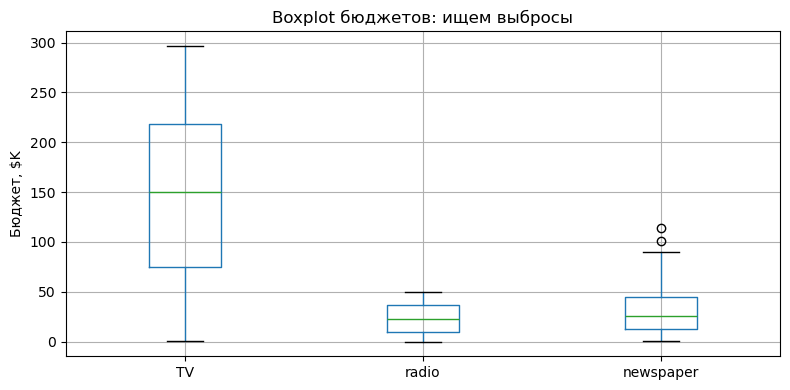

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df[['TV', 'radio', 'newspaper']].boxplot(ax=ax)
ax.set_title('Boxplot бюджетов: ищем выбросы')
ax.set_ylabel('Бюджет, $K')
plt.tight_layout()
plt.show()

На графике видно: у `newspaper` есть несколько точек выше верхнего уса — потенциальные выбросы (большие газетные кампании). У TV и radio — распределения более равномерные.

**Фильтрация по IQR на примере newspaper:**

In [9]:
q1, q3 = df['newspaper'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f'Допустимый диапазон newspaper: [{low:.1f}, {high:.1f}]')

outliers = df[(df['newspaper'] < low) | (df['newspaper'] > high)]
print(f'Выбросов: {len(outliers)} из {len(df)}')
outliers[['TV', 'radio', 'newspaper', 'sales']].head()

Допустимый диапазон newspaper: [-35.8, 93.6]
Выбросов: 2 из 200


,TV,radio,newspaper,sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


Видим конкретные строки-выбросы. На практике решение — выкидывать или нет — принимает доменный эксперт. Для линейной регрессии выбросы критичны: MSE-loss возводит ошибку в квадрат, и одна точка с гигантским newspaper-бюджетом может перетянуть на себя всю модель.

---

## Выбор колонок и фильтрация

Тепер базовые операции с DataFrame. **Запомни:** одинарные скобки → Series (одна колонка), двойные → DataFrame (несколько колонок). Эта пара скобок постоянно ставит новичков в тупик.

In [10]:
# Одна колонка → Series.
tv_budget = df['TV']
print(type(tv_budget))
tv_budget.head()

<class 'pandas.core.series.Series'>


0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
Name: TV, dtype: float64

In [11]:
# Список колонок → DataFrame.
df[['TV', 'radio']].head()

,TV,radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8


### Булева маска: фильтрация строк

Самая важная операция в pandas. Сравниваем колонку с условием → получаем массив `True`/`False` → подставляем в `df[...]` → остаются только строки, где `True`.

In [12]:
# Кампании с большим TV-бюджетом (>200K).
big_tv = df[df['TV'] > 200]
print(f'Кампаний с TV > 200K: {len(big_tv)}')
big_tv.head()

Кампаний с TV > 200K: 67


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
11,214.7,24.0,4.0,17.4
14,204.1,32.9,46.0,19.0
17,281.4,39.6,55.8,24.4
20,218.4,27.7,53.4,18.0


In [13]:
# Сложное условие через & (AND) и | (OR). Каждое условие в скобки!
balanced = df[(df['TV'] > 100) & (df['radio'] > 30)]
print(f'Сбалансированных кампаний (TV>100 AND radio>30): {len(balanced)}')

Сбалансированных кампаний (TV>100 AND radio>30): 47


Без скобок вокруг каждого условия Python поймёт `&` неправильно из-за приоритета операций. Это классическая ошибка начинающих.

---

## Matplotlib и seaborn: команды для графиков

Что мы будем вызывать:

- `sns.scatterplot(x, y, data)` — точечная диаграмма (как зависят y от x).
- `df.hist(bins=...)` — гистограммы по всем числовым колонкам.
- `sns.heatmap(corr, annot=True)` — тепловая карта (для матрицы корреляций).
- `sns.pairplot(df)` — все scatter-плоты попарно одной командой.

### Scatter: связь TV-бюджета и продаж

Сейчас построим scatterplot, чтобы посмотреть, есть ли вообще связь между бюджетом на TV-рекламу и продажами. Если связи нет — вся история с ML теряет смысл.

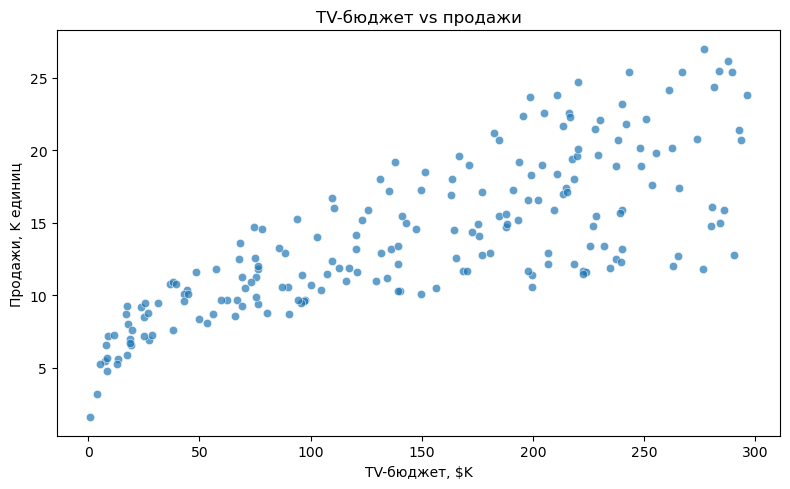

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='TV', y='sales', ax=ax, alpha=0.7)
ax.set_title('TV-бюджет vs продажи')
ax.set_xlabel('TV-бюджет, $K')
ax.set_ylabel('Продажи, K единиц')
plt.tight_layout()
plt.show()

На графике видно: чем больше TV-бюджет, тем выше продажи. Зависимость почти линейная, но при больших бюджетах разброс растёт (гетероскедастичность — наш будущий враг при оценке доверительных интервалов).

Это значит, что линейная модель `sales = a + b·TV` имеет смысл — тренд действительно есть.

### Гистограммы: распределение каждой колонки

Сейчас посмотрим на распределение каждой переменной отдельно. Гистограмма — это «сколько наблюдений попало в каждый интервал значений».

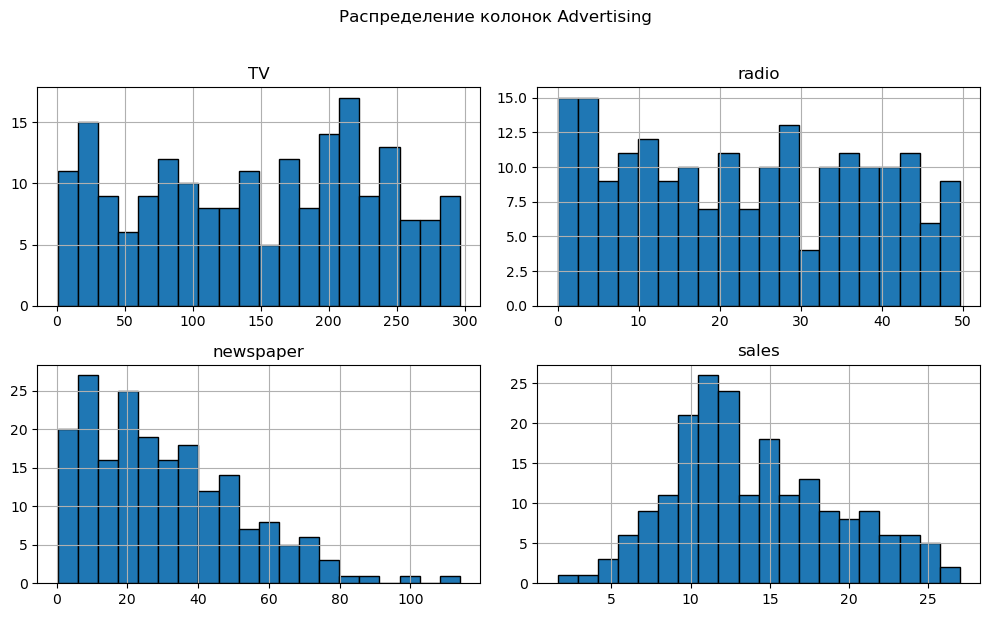

In [15]:
df.hist(bins=20, figsize=(10, 6), edgecolor='black')
plt.suptitle('Распределение колонок Advertising', y=1.02)
plt.tight_layout()
plt.show()

На графиках видно: TV распределён более-менее равномерно, radio имеет небольшой скос вправо, newspaper — заметный длинный хвост (несколько кампаний с очень большими газетными бюджетами). Это значит, что для линрега newspaper — самая «капризная» фича.

### Тепловая карта корреляций

Сейчас посчитаем корреляцию Пирсона между всеми парами колонок и нарисуем её как цветную таблицу. Это эффективный способ за один взгляд понять, какие фичи связаны с целевой переменной (`sales`) и какие — между собой (мультиколлинеарность).

> **Корреляция** — числовая мера того, как связаны две переменные. От −1 (идеальная отрицательная связь) до +1 (идеальная положительная); 0 — связи нет. Чаще всего используем коэффициент Пирсона — он смотрит на линейную связь.


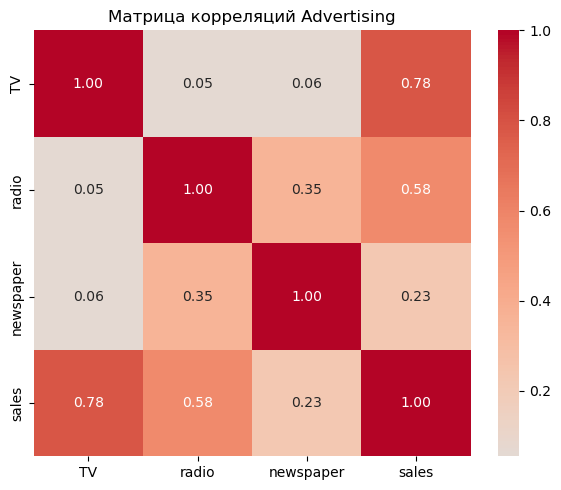

In [16]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Матрица корреляций Advertising')
plt.tight_layout()
plt.show()

На графике видно: TV сильно коррелирует с sales (0.78), radio — средне (0.58), newspaper — слабо (0.23). Между фичами корреляции тоже маленькие — значит мультиколлинеарности нет, можно спокойно пихать всё в линрег.

**Бизнес-вывод:** TV-бюджет — главный драйвер продаж в этом датасете.

---

## Numpy: основные команды

Что мы будем вызывать:

- `np.array([...])` — создать массив из списка.
- `arr.shape, arr.dtype` — размер и тип элементов.
- `arr.mean(), arr.std(), arr.sum()` — агрегации.
- `np.sqrt, np.log, np.exp` — векторизованная математика.
- `arr.to_numpy()` (для pandas Series/DataFrame) — конвертация в numpy-массив.

In [17]:
# Превращаем колонку sales в numpy-массив.
sales_arr = df['sales'].to_numpy()
print(f'shape: {sales_arr.shape}')
print(f'dtype: {sales_arr.dtype}')
print(f'первые 5: {sales_arr[:5]}')

shape: (200,)
dtype: float64
первые 5: [22.1 10.4  9.3 18.5 12.9]


In [18]:
# Векторизация: средний квадрат ошибки между sales и неким "baseline" 14.0.
baseline = np.full_like(sales_arr, 14.0)
mse_baseline = ((sales_arr - baseline) ** 2).mean()
print(f'MSE baseline=14: {mse_baseline:.3f}')

MSE baseline=14: 27.086


Без numpy пришлось бы писать Python-цикл `for s in sales: ...`. Векторизованный вариант не только короче, но и **в 50-100 раз быстрее** — под капотом работает скомпилированный C-код. Это и есть причина, по которой numpy/pandas — стандарт в ML.

### Операции: индексация, маски, broadcasting

In [19]:
X = df[['TV', 'radio', 'newspaper']].to_numpy()
y = df['sales'].to_numpy()
print(f'X: {X.shape}, y: {y.shape}')

X: (200, 3), y: (200,)


In [20]:
# Маска (булев индекс): только кампании с большими продажами.
high_sales_mask = y > 20
print(f'кампаний с продажами >20K: {high_sales_mask.sum()}')
X_high = X[high_sales_mask]
print(f'их фичи (shape): {X_high.shape}')

кампаний с продажами >20K: 31
их фичи (shape): (31, 3)


In [21]:
# Broadcasting: вычитаем среднее из каждой колонки X одной командой.
X_centered = X - X.mean(axis=0)
print(f'X.mean до центрирования по колонкам: {X.mean(axis=0).round(2)}')
print(f'X_centered.mean (должно быть ~0):    {X_centered.mean(axis=0).round(6)}')

X.mean до центрирования по колонкам: [147.04  23.26  30.55]
X_centered.mean (должно быть ~0):    [ 0. -0.  0.]


**Broadcasting** — это правило, по которому numpy автоматически растягивает массивы разной формы для покомпонентной операции. `X` имеет shape `(200, 3)`, `X.mean(axis=0)` — `(3,)`, и numpy сам понимает, что вычесть надо построчно. Этот трюк используется на каждом шагу в ML: нормализация фичей, центрирование, масштабирование.

---

## Что мы сделали

1. Подключили библиотеки для всего ML-блока (Jupyter уже стоит из week_00).
2. Загрузили реальный датасет (`pd.read_csv`) и посмотрели на него (`head`, `info`, `describe`).
3. Проверили чистоту данных: NaN, дубликаты, выбросы (boxplot + IQR).
4. Выбрали колонки и отфильтровали строки булевой маской.
5. Построили scatter + hist + heatmap, чтобы увидеть структуру данных глазами.
6. Превратили DataFrame в numpy-массив и попробовали векторизацию + broadcasting.

Дальше открой практический ноутбук того же примера — там 10 связанных упражнений на этот же датасет. Если застрянешь — посмотри решение.